1. Project Title

## NYC Airbnb Business Analysis


2. Objective

## Project Objective
Analyze Airbnb listings in New York City to understand pricing, neighbourhood performance, room-type distribution,
host activity, reviews, and availability, and identify useful business insights.

3. Import Libraries

 ## Step 3: Import Required Libraries
 We import the python libraries required for cleaning, analyzing, and visualizing the NYC Airbnb dataset.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

4. Load Dataset

## Step 4: Load Dataset
We load the Airbnb CSV file from its exact file path into a Pandas Dataframe named df.

In [5]:
df = pd.read_csv(r"C:\Users\Sreosree Roy\Documents\AB_NYC_2019.csv.zip")

5. First Five Records

## Step 5: Preview Dataset
We display the first five rows of the dataset to verify that the Airbnb data has loaded correctly.

In [6]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


6. Dataset Information

## Step 6: Check Dataset Information
We examine data types and non-null values to identify potential data-quality issues.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

7. Dataset Shape

## Step 7: Check Dataset Dimensions
We check the number of rows and columns to understand the overall size of Airbnb dataset.

In [8]:
df.shape

(48895, 16)

8. Column Names

## Step 8: Check Column Names
We list all column names to understand the variables available for business analysis.

In [9]:
df.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

9. Statistical Summary

## Step 9: Descriptive Statistics
We calculate descriptive statistics for numerical variables to understand their distribution and basic characteristics. 

In [10]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,38843.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.373221,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.680442,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.010000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.190000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.720000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,2.020000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


10. Check Missing Values

# Step 10: Check Missing Values
We identify missing values in each column to determine which variables require data cleaning.

In [15]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

11. Check Duplicate Records

## Step 11: Check Duplicate Records
We check for completely duplicated rows to ensure that duplicate records do not affect our analysis.

In [16]:
df.duplicated().sum()

np.int64(0)

12. Check Duplicate Listing IDs

## Step 12: Check Duplicate Listing IDs
We check whether any Airbnb listing IDs appear more than once to assess listing-level data consistency.

In [17]:
df['id'].duplicated().sum()

np.int64(0)

13. Check Room Types

## Step 13: Check Room Types
We identify the available room types to understand the different Airbnb accomodation options in the market.

In [18]:
df['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

14. Check Neighbourhood Groups

## Step 14: Check Neighbourhood Groups
We identify the neighbourhood groups represented in the dataset to understand the geographic coverage of Airbnb listings.

In [19]:
df['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

15. Handle Missing Listing Names

## Step 15: Handle Missing Listing Names
We replace missing listing names with "Unknown" so that missing text values do not interfere with analysis.

In [20]:
df['name']=df['name'].fillna('Unknown')






16. Handle Missing Host Names

## Step 16: Handle Missing Host Names
We replace missing  host names with "Unknown" to maintain consistent host information.

In [24]:
df['host_name']=df['host_name'].fillna('Unknown')

17. Handle Missing Review Activity

## Step 17: Handle Missing Review Activity
We replace missing monthly review values with zero because listings without recorded reviews have no measured monthly review activity.

In [25]:
df['reviews_per_month'] =df['reviews_per_month'].fillna(0)

18. Convert Review Date

## Step 18: Convert Review Date to Datetime Format
We convert the last review column into a proper date format so that review timing can be analyzed correctly.

In [26]:
df['last_review'] = pd.to_datetime(df['last_review'])

19. Create Price Category

## Step 19: Create Price Category
We categorize Airbnb listings into Budget, Mid-Range, Premium, and Luxury segments to support pricing analysis.

In [27]:
df['Price_Category'] = pd.cut(
    df['price'],
    bins=[-1, 100, 200, 500, np.inf],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

20. Create Availability Category

## Step 20: Create Availability Category
We categorize listings by annual availability to understand how frequently properties are available for booking.

In [28]:
df['Availability_Category'] = pd.cut(
    df['availability_365'],
    bins=[-1, 90, 180, 270, 365],
    labels=['Low', 'Moderate', 'High', 'Very High']
)

21. Create Review Activity Category

## Step 21: Create Review Activity Category
We classify listings according to their review volume to distinguish different levels of customer engagement.

In [29]:
df['Review_Activity'] = pd.cut(
    df['number_of_reviews'],
    bins=[-1, 0, 10, 50, 100, np.inf],
    labels=['No Reviews', 'Low', 'Moderate', 'High', 'Very High']
)

22. Inspect the Updated Dataset

## Step 22: Review the Transformed Dataset
The updated dataset is inspected to verify that the new analytical categories have been added successfully.

In [30]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,Price_Category,Availability_Category,Review_Activity
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,Mid-Range,Very High,Low
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,Premium,Very High,Moderate
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaT,0.00,1,365,Mid-Range,Very High,No Reviews
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,Budget,High,Very High
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,Budget,Low,Low


23. Listings by Neighbourhood Group

## Step 23: Listings by Neighbourhood Group
We count Airbnb listings in each neighbourhood group to understand where the Airbnb market is most concentrated.

In [31]:
listings_by_group = df['neighbourhood_group'].value_counts()
listings_by_group 

neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

24. Visualize Listings by Neighbourhood Group

## Step 24: Visualize Listings by Neighbourhood Group
We visualize listing counts by neighbourhood group to make geographic market concentration easier to compare.

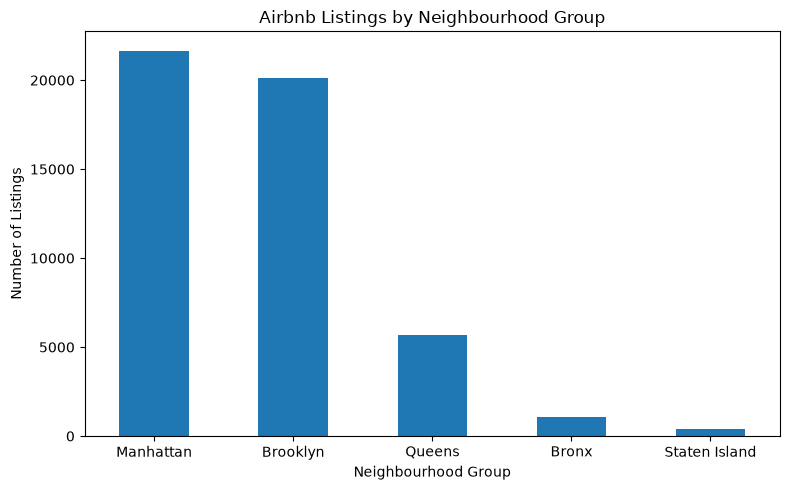

In [32]:
listings_by_group.plot(kind='bar', figsize=(8,5))
plt.title('Airbnb Listings by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Business Insight
Manhattan has the highest number of Airbnb listings, followed closely by Brooklyn. Together, Manhattan and Brooklyn account for
approximately 85% of all listings, showing that Airbnb supply is highly concentrated in these two neighbourhood groups.


25. Average Price by Neighbourhood Group

## Step 25: Average Price by Neighbourhood Group
We calculate the average listing price for each neighnourhood group to compare pricing across NYC markets.

In [33]:
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
avg_price

neighbourhood_group
Manhattan        196.875814
Brooklyn         124.383207
Staten Island    114.812332
Queens            99.517649
Bronx             87.496792
Name: price, dtype: float64

26. Visualize Average Price

## Step 26: Visualize Average Price
We visualize average prices across neighbourhood groups to identify higher- and lower-priced markets.

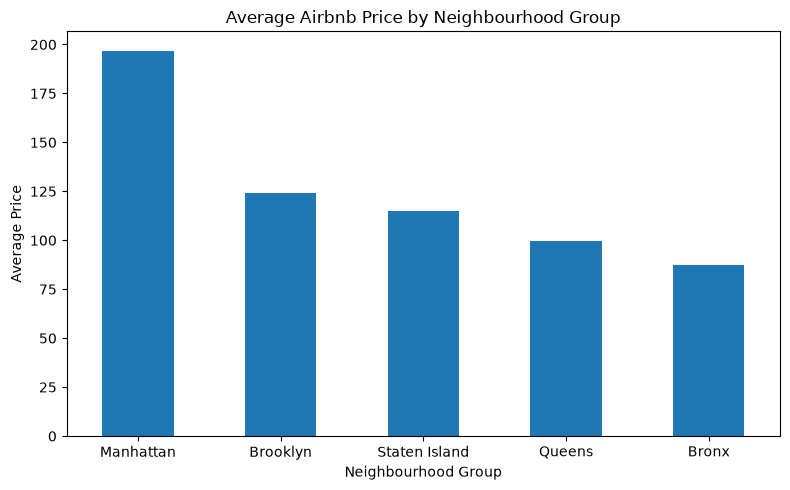

In [34]:
avg_price.plot(kind='bar', figsize=(8,5))

plt.title('Average Airbnb Price by Neighbourhood Group')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## Business Insight
Manhattan has the highest average Airbnb price, considerably above the other neighbourhood groups. This indicates that Manhattan
is the strongest, premium-pricing market in NYC, while the lower average prices in areas such as the Bronx and Queens may provide more
affordable options for guests and different pricing opportunities for hosts.

27. Room Type Distribution

## Step 27: Room Type Distribution
We count listings by room type to understand the composition of Airbnb accomodation available in NYC.

In [35]:
room_type_counts = df['room_type'].value_counts()
room_type_counts

room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64

28. Visualize Room Type Distribution

## Step 28: Visualize Room Type Distribution
We visualize room type counts to clearly compare the supply of different accomodation types.

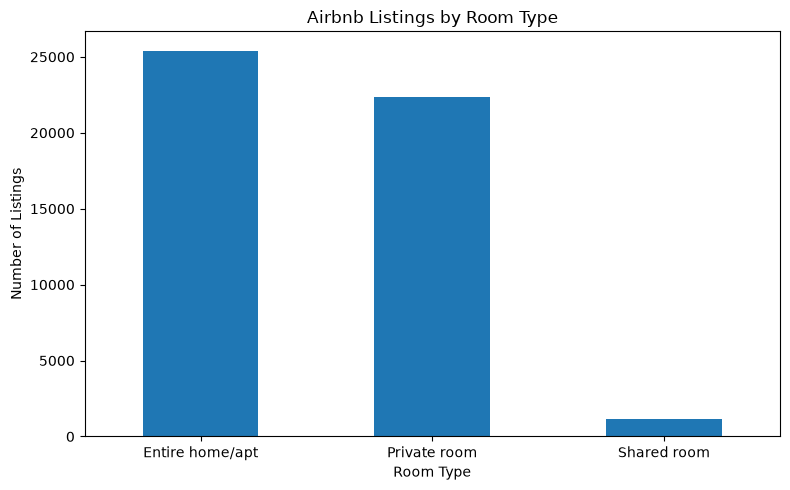

In [32]:
room_type_counts.plot(kind='bar', figsize=(8,5))

plt.title('Airbnb Listings by Room Type')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Business Insight
Entire homes/apartments and private rooms dominate the Airbnb market, while shared rooms account for only a very small share of listings.
This indicates that guests strongly prefer private accomadation, making entire homes/apartments and private rooms the key segments for Airbnb hosts
and property managers.   

29. Average Price by Room Type

## Step 29: Average Price by Room Type
We calculate average prices for each room type to compare the pricing of different accomodation formats.

In [36]:
avg_price_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)
avg_price_room

room_type
Entire home/apt    211.794246
Private room        89.780973
Shared room         70.127586
Name: price, dtype: float64

30. Top 10 Neighbourhoods by Listing Count

## Step 30: Top 10 Neighbourhoods by Listing Count
We identify the ten neighbourhoods with the highest number of listings to locate the strongest concentrations of Airbnb supply.

In [37]:
top_neighbourhoods = (df['neighbourhood'].value_counts().head(10))
top_neighbourhoods

neighbourhood
Williamsburg          3920
Bedford-Stuyvesant    3714
Harlem                2658
Bushwick              2465
Upper West Side       1971
Hell's Kitchen        1958
East Village          1853
Upper East Side       1798
Crown Heights         1564
Midtown               1545
Name: count, dtype: int64

31. Top 10 Neighbourhoods by Average Price

## Step 31: Top 10 Neighbourhoods by Average Price
We calculate average prices by neighbourhood and identify the ten highest-priced markets with sufficient listing volume.

In [38]:
premium_neighbourhoods = (
    df.groupby('neighbourhood')
    .agg(
        listing_count=('id', 'count'),
        average_price=('price', 'mean')
    )
    .query('listing_count >=100')
    .sort_values('average_price', ascending=False)
    .head(10)
)

premium_neighbourhoods   

,listing_count,average_price
neighbourhood,,
Tribeca,177,490.638418
SoHo,358,287.103352
Midtown,1545,282.719094
West Village,768,267.682292
Greenwich Village,392,263.405612
Chelsea,1113,249.738544
Theater District,288,248.013889
Nolita,253,230.138340
Financial District,744,225.490591


32: Price vs Number of Reviews

## Step 32: Price vs Number of Reviews
We compare listing prices with review counts to explore whether pricing is associated with customer engagement.

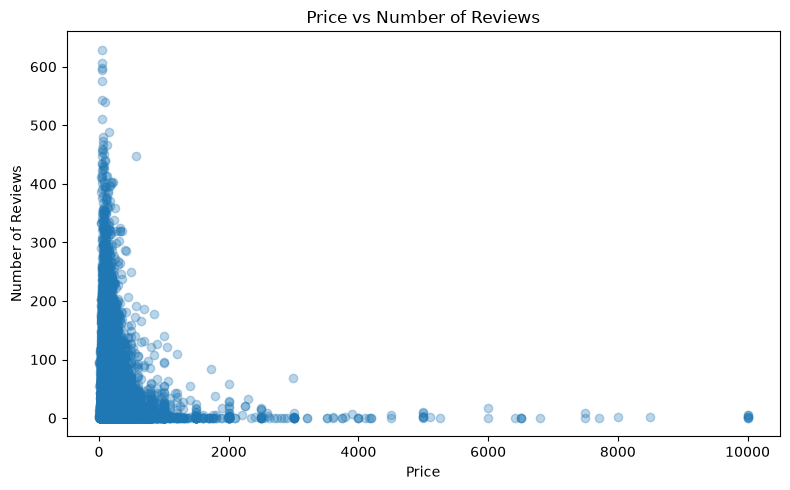

In [39]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['price'],
    df['number_of_reviews'],
    alpha=0.3
)

plt.title('Price vs Number of Reviews')
plt.xlabel('Price')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## Business Insight
The scatter plot shows that Airbnb listings with different price levels can receive a wide range of reviews, with no strong clear
relationship between price and review volume. This suggests that higher pricing alone does not guarantee greater customer engagement,
so hosts should consider factors such as location, accomodation type, availability, and overall guest experience when setting prices.

33. Availability by Room Type

## Step 33: Availability by Room Type
We calculate average annual availability by room type to understand differences in booking availability.

In [40]:
availability_room = (df.groupby('room_type')['availability_365'].mean().sort_values(ascending=False))
availability_room

room_type
Shared room        162.000862
Entire home/apt    111.920304
Private room       111.203933
Name: availability_365, dtype: float64

34. Reviews by Neighbourhood Group

## Step 34: Reviews by Neighbourhood Group
We calculate average review counts by neighbourhood group to compare customer engagement across markets.

In [41]:
reviews_group = (df.groupby('neighbourhood_group')['number_of_reviews'].mean().sort_values(ascending=False))
reviews_group 

neighbourhood_group
Staten Island    30.941019
Queens           27.700318
Bronx            26.004583
Brooklyn         24.202845
Manhattan        20.985596
Name: number_of_reviews, dtype: float64

35. Top Hosts by Number of Listings

## Step 35: Top Hosts by Number of Listings
We count listings by host to identify hosts with significant control over Airbnb supply.

In [42]:
top_hosts = (
    df.groupby(['host_id', 'host_name'])
    .size()
    .reset_index(name='listing_count')
    .sort_values('listing_count', ascending=False)
    .head(10)
)
top_hosts

,host_id,host_name,listing_count
34646,219517861,Sonder (NYC),327
29407,107434423,Blueground,232
19574,30283594,Kara,121
31079,137358866,Kazuya,103
12806,12243051,Sonder,96
14436,16098958,Jeremy & Laura,96
25662,61391963,Corporate Housing,91
17091,22541573,Ken,87
33868,200380610,Pranjal,65
3044,1475015,Mike,52


36. Price Category Distribution

## Step 36: Price Category Distribution
We count listings within each price category to understand the overall pricing structure of the NYC Airbnb market.

In [43]:
price_category_counts = df['Price_Category'].value_counts()
price_category_counts

Price_Category
Budget       23928
Mid-Range    16583
Premium       7340
Luxury        1044
Name: count, dtype: int64

37. Availability Category Distribution

## Step 37: Availability Category Distribution
We count listings within each availability category to understand how frequently Airbnb properties are available throughout the year.

In [44]:
availability_category_counts = df['Availability_Category'].value_counts()
availability_category_counts

Availability_Category
Low          29246
Very High     9851
Moderate      5285
High          4513
Name: count, dtype: int64

38. Review Activity Distribution

## Step 38: Review Activity Distribution
We count listings across review activity categories to understand customer engagement levels.

In [45]:
review_activity_counts = df['Review_Activity'].value_counts()
review_activity_counts

Review_Activity
Low           20271
Moderate      11613
No Reviews    10052
High           3964
Very High      2995
Name: count, dtype: int64

39. Key Business Metrics

## Step 39: Key Business Metrics
We calculate key portfolio metrics that summarize the size, pricing, customer engagement, and availability of the Airbnb market.

In [46]:
total_listings = df['id'].nunique()
average_price = df['price'].mean()
average_reviews = df['number_of_reviews'].mean()
average_availability = df['availability_365'].mean()

print("Total Listings:" , total_listings)
print("Average Price:" , round(average_price,2))
print("Average Reviews:" , round(average_reviews,2))
print("Average Availability:" , round(average_availability,2))

Total Listings: 48895
Average Price: 152.72
Average Reviews: 23.27
Average Availability: 112.78


## Final Business Insights
1.Airbnb listings are heavily concentrated in Manhattan and brooklyn, making these the most important markets by listing supply.

2.Manhattan commands the highest average Airbnb prices, indicating a strong premium market driven by location.

3.Entire homes/apartments and private rooms dominate the market, while shared rooms represent only a small portion of listings.

4.Price does not show a strong clear relationship with the number of reviews, suggesting that factors beyond price influence customer engagement.

5.Overall, location, room type, pricing, availability, and customer segment should be considered together when making Airbnb pricing and market decisions.


## Final Step: Export the Final Cleaned Dataset

In [47]:
df. to_csv('NYC_Airbnb_Business_Analysis_Cleaned.csv', index=False)